In [2]:
import pandas as pd

risk_scores = pd.read_csv("../data/customer_risk_scores.csv")
sentiment = pd.read_csv("../data/review_sentiment.csv")
clean_orders = pd.read_csv("../data/clean_orders.csv")

print(risk_scores.shape, sentiment.shape, clean_orders.shape)

(93358, 7) (1817, 4) (96478, 10)


In [3]:
order_customer_map = clean_orders[["order_id", "customer_unique_id"]].drop_duplicates()

sentiment_with_customer = sentiment.merge(order_customer_map, on="order_id", how="left")
sentiment_with_customer = sentiment_with_customer.dropna(subset=["customer_unique_id"])

print(sentiment_with_customer.shape)
sentiment_with_customer.head()

(1741, 5)


,order_id,review_score,sentiment_score,sentiment_label,customer_unique_id
0,301b453872955e08f7aed322d6a0753a,4,0.2732,Positive,3defdac1cf5b779689353f537aa723d6
1,f9281da15642bc69f27307e1dc987b30,5,0.4404,Positive,93f105f20edb24e18548b88b8accdca3
2,e747b099854432937d27178c640102bf,5,0.0000,Neutral,a76755933c997e2d5a1cf81a3db71e8e
3,3f3e4083688c07129239450773e84282,5,0.0000,Neutral,62d514474504de66057183274ece334a
4,b3b8133868458b6acf08ea6ffc22e3f2,5,0.7845,Positive,8f0eb363ad943a36b7091034f29b508e


In [4]:
customer_sentiment = sentiment_with_customer.groupby("customer_unique_id")["sentiment_score"].mean().reset_index()
customer_sentiment.columns = ["customer_unique_id", "avg_sentiment_score"]

print(customer_sentiment.shape)
customer_sentiment.head()

(1739, 2)


,customer_unique_id,avg_sentiment_score
0,008778a1591d49f6b2464dffaa4fa662,0.4201
1,009000746b4fc73fe77ecc396fdb78d2,0.3382
2,00e8cbf31206edcf22b7b118daa13983,0.2960
3,012452d40dafae4df401bced74cdb490,0.4927
4,013341d7f8accddf42fc02f001ad341d,0.4927


In [5]:
final = risk_scores.merge(customer_sentiment, on="customer_unique_id", how="left")

print(final.shape)
print("Customers with sentiment data:", final["avg_sentiment_score"].notna().sum())
final.head()

(93358, 8)
Customers with sentiment data: 1739


,customer_unique_id,recency,frequency,monetary,churned,churn_probability,risk_tier,avg_sentiment_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0,0.488787,Low,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0,0.514851,High,NaN
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,0.489982,Low,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1,0.511133,High,NaN
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1,0.494818,Medium,NaN


In [6]:
final.groupby("risk_tier")["avg_sentiment_score"].agg(["mean", "count"])

,mean,count
risk_tier,,
High,0.320018,568
Low,0.267729,603
Medium,0.305456,568


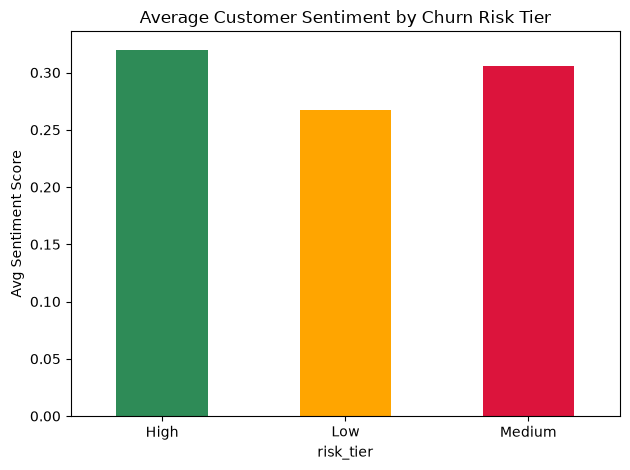

In [7]:
import matplotlib.pyplot as plt

final.groupby("risk_tier")["avg_sentiment_score"].mean().plot(kind="bar", color=["seagreen", "orange", "crimson"])
plt.title("Average Customer Sentiment by Churn Risk Tier")
plt.ylabel("Avg Sentiment Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../dashboard/sentiment_by_risk_tier.png", dpi=150)
plt.show()

In [9]:
final["avg_sentiment_score"] = pd.to_numeric(final["avg_sentiment_score"], errors="coerce")
final.to_csv("../data/final_customer_dataset.csv", index=False)

## Day 9 Notes — Sentiment vs Churn Risk
- Merged sentiment scores (Day 8) with customer risk tiers (Day 7) via order_id -> customer_unique_id
- 1,739 of ~93K customers have a matching sentiment score (limited by the 1,817-review
  translated sample from Day 8)
- Average sentiment by tier: High 0.320 (n=568), Medium 0.305 (n=568), Low 0.268 (n=603)
- Finding: sentiment does NOT show the expected pattern (lower sentiment -> higher risk).
  All tiers are close and mildly positive, with High risk actually scoring slightly higher.
- This is consistent with Day 6's finding that the RFM-based churn model has weak predictive
  power (ROC-AUC ~0.56) — since risk_tier is a weak signal to begin with, it's unsurprising
  it doesn't show a strong relationship with sentiment either.
- Honest conclusion: in this dataset, review sentiment and RFM-based churn risk appear to be
  largely independent signals. A stronger churn model (with richer features) would be needed
  to properly test whether sentiment adds predictive value.
- final_customer_dataset.csv is saved as the single source of truth for the dashboard (Day 10)